In [36]:
import glob
import fitsio
from astropy.table import Table
import matplotlib.pyplot as plt
import numpy as np
import healpy as hp
from scipy.stats import binned_statistic


In [37]:
randoms=fitsio.FITS('/user/animesh.sah/FP_CUTS/randoms_with_mags.fits')[1].read()
randoms =randoms[randoms['DEC']>-30]


In [38]:
def plot_map(map,nside=1024):
    hp.mollview(map, title="Map", cmap='Blues', norm='hist', cbar=False,unit= 'Counts')
    hp.graticule()
    plt.show()
def get_mask(ra,dec,nside):
    theta = np.radians(90 -dec)
    phi = np.radians(ra)
    pix = hp.ang2pix(nside, theta, phi)
    mask = np.bincount(pix, minlength=hp.nside2npix(nside))
    mask = np.where(mask>0, 1, 0)
    return mask
def points_to_map(ra_deg, dec_deg, nside, weights=None):
    theta = np.radians(90.0 - dec_deg)  
    phi   = np.radians(ra_deg)
    ipix  = hp.ang2pix(nside, theta, phi, nest=False)
    npix  = hp.nside2npix(nside)
    if weights is None:
        weights = np.ones_like(ipix, dtype=np.float64)
    m = np.bincount(ipix, weights=weights, minlength=npix).astype(np.float64)
    return m
# def plot_map(map,nside=1024):
#     hp.mollview(map, title="Map", cmap='Blues', norm='hist', cbar=False,unit= 'Counts')
#     hp.graticule()
#     plt.show()

# def create_rand_map(part,nside):
#     random_compiled = randoms
#     rand_table=Table(random_compiled)
#     rand_table = rand_table[rand_table['DEC'] > -30]

#     if part == 'N':
#         rand_table = rand_table[rand_table['PHOTSYS'] == 'N']
#     elif part == 'S':
#         rand_table = rand_table[rand_table['PHOTSYS'] == 'S']
#     RA_random = np.ascontiguousarray(np.array(rand_table['RA'], dtype=np.float64))
#     DEC_random= np.ascontiguousarray(np.array(rand_table['DEC'], dtype=np.float64))
#     rand_map = get_mask(RA_random, DEC_random, nside)
#     return rand_map
# north_masks={}
# south_masks={}
# full_masks={}

# # for nside in [32,64,128,256]:
# #     north_masks[nside] = create_rand_map('N',nside)
# #     south_masks[nside] = create_rand_map('S',nside)
# #     full_masks[nside]  = create_rand_map(None,nside)

# for masks in [north_masks, south_masks, full_masks]:
#     for nside in masks:
#         # Determine the region name based on the variable name
#         if masks is north_masks:
#             region = "north"
#         elif masks is south_masks:
#             region = "south"
#         else:
#             region = "full"
#         hp.write_map(f"{region}_mask_nside_{nside}.fits", masks[nside], overwrite=True)

In [39]:
north_masks={}
south_masks={}
full_masks={}

for region in ['north', 'south', 'full']:
    if region == 'north':
        target_dict = north_masks
    elif region == 'south':
        target_dict = south_masks
    else:
        target_dict = full_masks
    
    for nside in [32,64,128,256]:
        target_dict[nside] = hp.read_map(f"{region}_mask_nside_{nside}.fits")

In [40]:
# hp.mollview(full_masks[256], cmap='Greys', title="DESI Footprint Mask at NSIDE=256", nest=False)
# hp.graticule()

In [41]:
target_dict[64]

array([0, 0, 0, ..., 0, 0, 0], dtype='>i8')

In [42]:
data={}
data['full'] = Table(fitsio.FITS('../table_match_final.fits')[1].read())
data['north'] = Table(fitsio.FITS(f'../../FP_CUTS/table_north_unique.fits')[1].read())
data['north']= data['north'][data['north']['DEC']>10]

data['south'] = Table(fitsio.FITS(f'../../FP_CUTS/table_south_unique.fits')[1].read())

In [43]:
n_objects_ref=328831
area_north=5167.3 
area_south=12213.4

In [44]:
np.mean(points_to_map(data['north']['RA'], data['north']['DEC'], nside=32)[north_masks[32]==1])


85.474251497006

In [45]:
# Calculate number of objects per pixel for data['full'] at different nside values
nside_values_obj = [32,64, 128, 256]
#nside_values_obj = [32]

for nside_obj in nside_values_obj:
    print(f"\nAnalyzing nside = {nside_obj}")
    counts_data = points_to_map(data['full']['RA'], data['full']['DEC'], nside=nside_obj)
    npix_obj = hp.nside2npix(nside_obj)
    pixarea_obj = hp.nside2pixarea(nside_obj, degrees=True)
    print(f"Total pixels: {npix_obj}")
    print(f"Pixel area: {pixarea_obj:.6f} deg²")
    if nside_obj in full_masks:
        mask = full_masks[nside_obj]
    else:
        print(f"Mask for nside {nside_obj} not found.")
        continue
    for region_name in ['full','north', 'south']:
        try:
            mask = eval(f"{region_name}_masks")[nside_obj]
        except KeyError:
            continue
        ra_data, dec_data = data[region_name][['RA', 'DEC']].to_pandas().values.T
        counts_data = points_to_map(ra_data, dec_data, nside=nside_obj)
        print(f"\nRegion: {region_name.capitalize()}")
        print(f'Total objects in data: {len(data[region_name])}')
        
        print(f'-'*60)

        print(f'Mean number of objects in non zero pixels: {np.mean(counts_data[counts_data > 0])}')
        print(f'Mean number of objects in the valid mask pixels: {np.mean(counts_data[mask==1])}')
        print(f'-'*60)
        print(f'Median number of objects in non zero pixels: {np.median(counts_data[counts_data > 0])}')
        print(f'Median number of objects in the valid mask pixels: {np.median(counts_data[mask==1])}')
        print(f'-'*60)
        print(f'Number of pixels with zero counts in the valid mask: {(counts_data[mask==1] == 0).sum()}, while non zero pixels are {(counts_data[mask==1] != 0).sum()}')
    print('\n')
    print('='*60)

        


Analyzing nside = 32
Total pixels: 12288
Pixel area: 3.357175 deg²

Region: Full
Total objects in data: 480896
------------------------------------------------------------
Mean number of objects in non zero pixels: 91.52950133231823
Mean number of objects in the valid mask pixels: 87.67474931631723
------------------------------------------------------------
Median number of objects in non zero pixels: 85.0
Median number of objects in the valid mask pixels: 83.0
------------------------------------------------------------
Number of pixels with zero counts in the valid mask: 231, while non zero pixels are 5254

Region: North
Total objects in data: 142742
------------------------------------------------------------
Mean number of objects in non zero pixels: 87.0909090909091
Mean number of objects in the valid mask pixels: 85.474251497006
------------------------------------------------------------
Median number of objects in non zero pixels: 81.0
Median number of objects in the valid ma

In [46]:
def pixel_median(ra_array, dec_array,values,nside = 64):
    theta = np.radians(90.0 - dec_array)
    phi = np.radians(ra_array)
    pix = hp.ang2pix(nside, theta, phi,nest=True)
    npix  = hp.nside2npix(nside)
    pixarea = hp.nside2pixarea(nside, degrees=True)  # in square degrees
    order = np.argsort(pix)
    pix_sorted = pix[order]
    _, idx = np.unique(pix_sorted, return_index=True)
    idx = np.append(idx,len(pix_sorted))
    arr = values[order]
    out = np.full(npix, np.nan)
    for i in range(len(idx)-1):
        start, end = idx[i], idx[i+1]
        p = pix_sorted[start]
        out[p] = np.median(arr[start:end])
    return out


#Alternate method to compute median per pixel using binned_statistic
# median_vals = {}
# for val in ['EBV']:  
#     medians, _, _ = binned_statistic(
#             pix, randoms_sampled[val], statistic='median', bins=npix, range=[0, npix]
#         )
#     median_vals[val] = medians
#     print('Done with ', val)
     

In [47]:
colnames = [colname for colname in randoms.dtype.names if ('PSF' in colname) or ('GALDEPTH' in colname)  or ('GALMAG' in colname)  or ('MASKBITS' in colname) or ('NOBS' in colname) or ('EBV' in colname) or ('STARDENS' in colname) or ('HPXPIXEL' in colname) or ('MW_TRANSMISSION' in colname) or  ('FRACAREA' in colname) or ('FRACMASKED' in colname) or ('FRACFLUX' in colname) or ('FRACIN' in colname) ] 
colnames = ['PSFDEPTH_Z','PSFDEPTH_G','PSFDEPTH_R','PSFSIZE_G','PSFSIZE_R','PSFSIZE_Z']
# Randomly sample 20000 points
n_sample = min(5_000_000, len(randoms))
indices = np.random.choice(len(randoms), size=n_sample, replace=False)

ra_array_full = randoms['RA'][indices]
dec_array_full = randoms['DEC'][indices]
randoms_full = randoms[indices]

randoms_south = randoms_full[randoms_full['PHOTSYS'] == 'S']
randoms_north = randoms_full[randoms_full['PHOTSYS'] == 'N']




# counts = np.bincount(pix, minlength=npix)  
# fracarea = counts / counts.max()



In [48]:
# npix = hp.nside2npix(nside)

# for val in colnames:
#     pix_indices = hp.ang2pix(nside, np.radians(90.0 - randoms_full['DEC']), np.radians(randoms_full['RA']),nest=True)
#     hpx_map = np.full(npix, hp.UNSEEN)
    
#     for pix in np.unique(pix_indices):
#         mask = pix_indices == pix
#         hpx_map[pix] = np.median(randoms_full[val][mask])
#     hp.mollview(hpx_map, cmap='jet', unit=f"{val}", title=f"{val} Sky Map (nside={nside})", nest=True)
#     hp.graticule()
#     plt.show()

In [49]:
for val in colnames:
    dat = randoms_full[val]
    # Create map with mean value per pixel
    hpx_map = np.zeros(npix, dtype=float)
    pix_indices = hp.ang2pix(nside, np.radians(90.0 - randoms_full['DEC']), np.radians(randoms_full['RA']), nest=True)
    hpx_map[:] = hp.UNSEEN
    for pix in np.unique(pix_indices):
        mask = pix_indices == pix
        hpx_map[pix] = np.mean(dat[mask])
    hp.mollview(hpx_map, cmap='jet', unit=f"{val}", title=f"{val} Sky Map (nside={nside})", nest=True)
    hp.graticule()
    plt.show()


KeyboardInterrupt: 

In [ ]:
# Filter masks to remove pixels with coverage lower than 90%
# coverage_threshold = 0.9
# for nside_val in [32, 64, 128, 256]:
#     # Create coverage maps for each region using randoms
#     for region_name, masks_to_update in [('full', full_masks), ('north', north_masks), ('south', south_masks)]:
#         # Get the appropriate randoms subset
#         if region_name == 'north':
#             randoms_subset = randoms[randoms['PHOTSYS'] == 'N']
#         elif region_name == 'south':
#             randoms_subset = randoms[randoms['PHOTSYS'] == 'S']
#         else:
#             randoms_subset = randoms
        
#         # Calculate coverage per pixel
#         npix = hp.nside2npix(nside_val)
#         theta = np.radians(90.0 - randoms_subset['DEC'])
#         phi = np.radians(randoms_subset['RA'])
#         pix = hp.ang2pix(nside_val, theta, phi, nest=False)
        
#         # Count randoms per pixel
#         counts = np.bincount(pix, minlength=npix)
        
#         # Estimate coverage (normalized by maximum count)
#         max_count = counts.max()
#         coverage = counts / max_count
        
#         # Update mask: keep only pixels with coverage >= threshold
#         coverage_mask = (coverage >= coverage_threshold).astype(int)
#         masks_og = masks_to_update[nside_val].copy()
#         masks_to_update[nside_val] = masks_to_update[nside_val] * coverage_mask
        
#         print(f"Region: {region_name}, nside: {nside_val}, Pixels removed: {(masks_og[nside_val] == 0).sum() - (coverage_mask == 0).sum()}")

# print("\nMasks updated to exclude pixels with coverage < 90%")

Region: full, nside: 32, Pixels removed: -7353
Region: north, nside: 32, Pixels removed: -10838
Region: south, nside: 32, Pixels removed: -8856
Region: full, nside: 64, Pixels removed: -29120
Region: north, nside: 64, Pixels removed: -43268
Region: south, nside: 64, Pixels removed: -35226
Region: full, nside: 128, Pixels removed: -183298
Region: north, nside: 128, Pixels removed: -186806
Region: south, nside: 128, Pixels removed: -187293
Region: full, nside: 256, Pixels removed: -784717
Region: north, nside: 256, Pixels removed: -785943
Region: south, nside: 256, Pixels removed: -784973

Masks updated to exclude pixels with coverage < 90%


In [106]:
feature_raw = points_to_map(randoms['RA'], randoms['DEC'], nside=64, weights=randoms['PSFSIZE_Z'])
counts_map = points_to_map(randoms['RA'], randoms['DEC'], nside=64)

# Avoid division by zero
pix = np.zeros_like(feature_raw)
valid_pixels = counts_map > 0
pix[valid_pixels] = feature_raw[valid_pixels] / counts_map[valid_pixels]

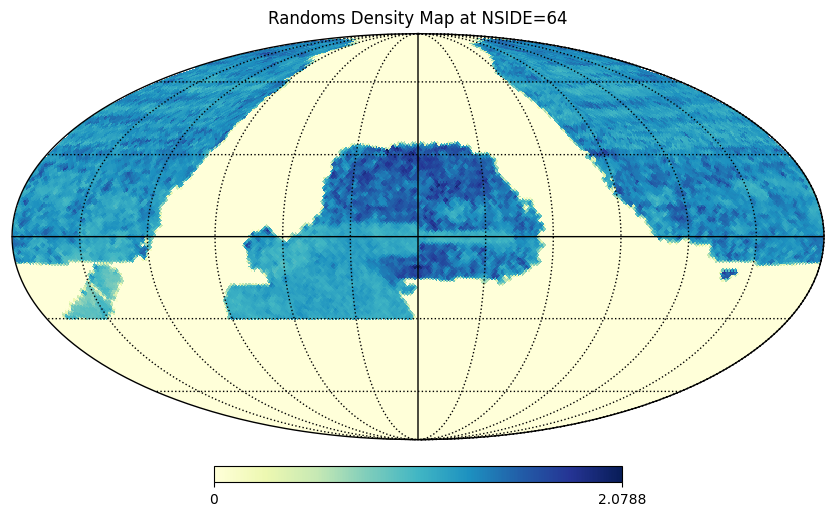

In [107]:
hp.mollview(pix, cmap='YlGnBu', title="Randoms Density Map at NSIDE=64", nest=False)
hp.graticule()




In [50]:
csfd_map = hp.read_map('/user/animesh.sah/csfd_maps/csfd_ebv.fits')
csfd_mask = hp.read_map('/user/animesh.sah/csfd_maps/mask.fits')
lss_error_map = hp.read_map('/user/animesh.sah/csfd_maps/lss_error.fits')
lss_intensity_map = hp.read_map('/user/animesh.sah/csfd_maps/lss_intensity.fits')
COSMO_BIT = 2
cosmo_mask = (csfd_mask & (1 << COSMO_BIT)) > 0   # boolean mask array
lss_cosmo = np.where(cosmo_mask, lss_intensity_map, hp.UNSEEN)


csfd_cosmo = np.where(cosmo_mask, csfd_map, hp.UNSEEN)  
# hp.mollview(csfd_map, cmap='inferno', unit="Corrected E(B-V)",min =5e-3,max= 2, norm= 'log',title=f" Corrected E(B-V) Sky Map", nest=False)
# hp.graticule()
# plt.show()
rotator = hp.Rotator(coord=['G', 'C'])

# Downgrade csfd_map to nside=256
nside_target = [32,64,128]
csfd_map_nside= {}
csfd_map_eq = rotator.rotate_map_pixel(csfd_map)

for nside in nside_target:

    csfd_map_nside[nside] = hp.ud_grade(csfd_map_eq, nside_out=nside, order_in='RING', order_out='RING', power=0)
    print(f"Downgraded csfd_map to nside={nside}, shape: {csfd_map_nside[nside].shape}")
# hp.mollview(csfd_map_nside[64], cmap='inferno', unit="Corrected E(B-V)",min =5e-3,max= 2, norm= 'log',title=f" Corrected E(B-V) Sky Map nside=64", nest=False)
# hp.graticule()
# plt.show()





Downgraded csfd_map to nside=32, shape: (12288,)
Downgraded csfd_map to nside=64, shape: (49152,)
Downgraded csfd_map to nside=128, shape: (196608,)


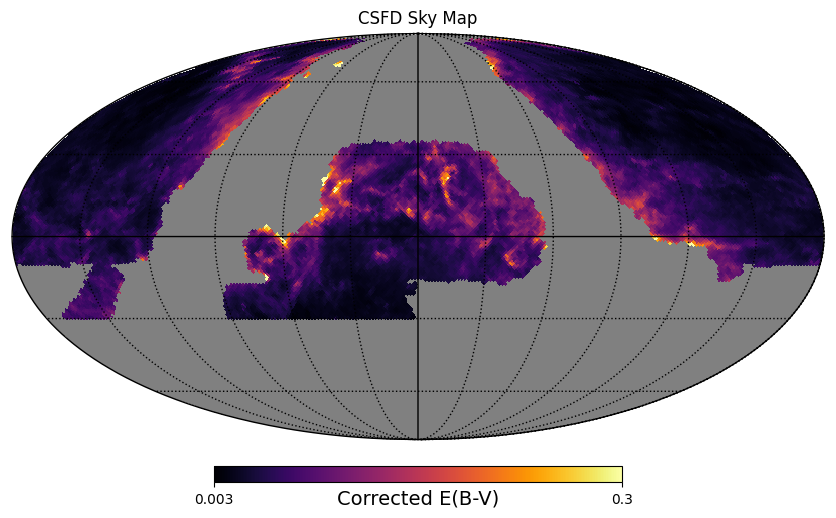

In [51]:
csfd_masked_desi =csfd_map_nside[64]*full_masks[64]

masked = np.where(full_masks[64], csfd_masked_desi, hp.UNSEEN)
hp.mollview(masked, cmap='inferno', unit="Corrected E(B-V)", min=3e-3, max=0.3, title="CSFD Sky Map", cbar=True, notext=False, )
hp.graticule()
plt.show()

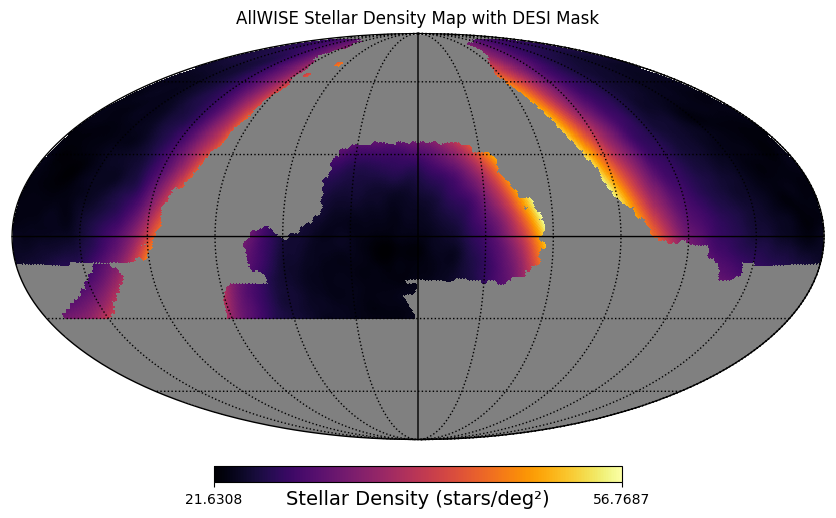

In [52]:
stellar_density_allwise = hp.read_map('/user/animesh.sah/Stellar_density/allwise_total_rot_1024.fits')
stellar_density_allwise_nside = {}
for nside in nside_target:
    stellar_density_allwise_nside[nside] = hp.ud_grade(stellar_density_allwise, nside_out=nside, order_in='RING', order_out='RING', power=0)
#hp.mollview(stellar_density_allwise_nside[128], cmap='inferno', unit="Stellar Density (stars/deg²)", title="AllWISE Stellar Density Map", nest=False)
stellar_density_allwise_128_DESI  = np.where(full_masks[128], stellar_density_allwise_nside[128], hp.UNSEEN)

hp.mollview(stellar_density_allwise_128_DESI, cmap='inferno', unit="Stellar Density (stars/deg²)", title="AllWISE Stellar Density Map with DESI Mask", nest=False)
hp.graticule()

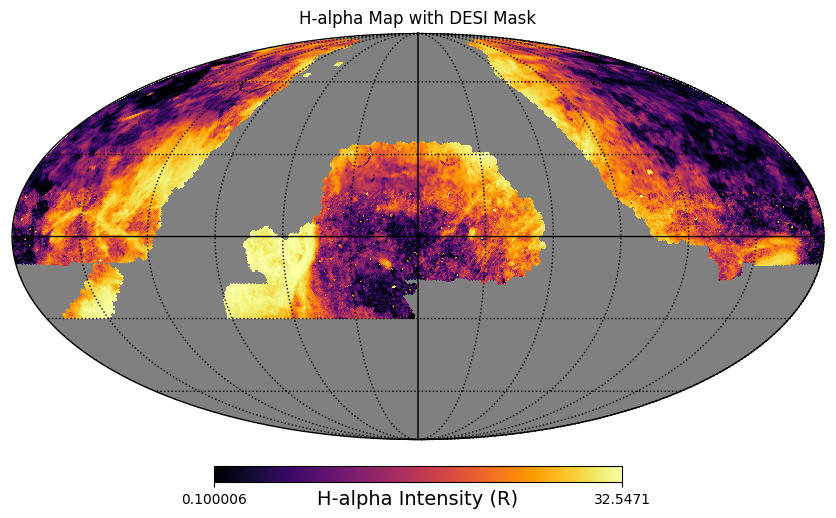

In [53]:
h_alpha = hp.read_map('/user/animesh.sah/Halpha_maps/Halpha_fwhm06_1024.fits')
h_alpha_nside = {}
h_alpha_eq = rotator.rotate_map_pixel(h_alpha)

plt.show()
for nside in nside_target:
    h_alpha_nside[nside] = hp.ud_grade(h_alpha_eq, nside_out=nside, order_in='RING', order_out='RING', power=0)

h_alpha_128_DESI = np.where(full_masks[128], h_alpha_nside[128], hp.UNSEEN) 
hp.mollview(h_alpha_128_DESI, cmap='inferno',unit="H-alpha Intensity (R)",norm='hist', title="H-alpha Map with DESI Mask", nest=False)
hp.graticule()
plt.show()

In [ ]:
import os
# os.makedirs('imaging_systematics_maps', exist_ok=True)
# nside = 128
# median_map = {}
# for val in colnames:
#     median_map[val] = pixel_median(randoms_south['RA'], randoms_south['DEC'], randoms_south[val], nside=nside)
#     print('Done with ', val)

# for val in colnames:
#     hp.mollview(median_map[val], cmap='jet', unit=f"{val}", title=f"{val} Sky Map (nside={nside})", nest=True)
#     hp.graticule()
#     plt.savefig(f'imaging_systematics_maps/{val}_nside{nside}_south.png')
#     plt.show()




In [ ]:
import os
os.makedirs('imaging_systematics_maps', exist_ok=True)

# Create median maps for all regions and nsides
median_maps = {}

# Define regions and their corresponding data
regions = {
    'full': randoms_full,
    'north': randoms_north,
    'south': randoms_south
}

masks_dict= {
    'full': full_masks,
    'north': north_masks,
    'south': south_masks
}


# Process all regions and nsides
nside_values_obj = [32, 64, 128]
nside_values_obj = [32,64,128]

for region_name, region_data in regions.items():
    median_maps[region_name] = {}
    
    for nside_val in nside_values_obj:
        median_maps[region_name][nside_val] = {}
        
        print(f"\nProcessing {region_name} region at nside={nside_val}")
        
        for val in colnames:
            if 'PSFDEPTH' in val:
                psfmag = region_data[val]
                valid_mask = psfmag > 0
                # Initialize with NaN
                depth_val = np.full(len(psfmag), np.inf, dtype=np.float32)  #healpy maps are better at dealing with inf than nan

                #Only compute for valid (non-zero) values
                depth_val[valid_mask] = -2.5 * (np.log10(5 / np.sqrt(psfmag[valid_mask])) - 9)
                map = pixel_median(
                    region_data['RA'], 
                    region_data['DEC'], 
                    depth_val, 
                    nside=nside_val
                )
             
            else:
                map = pixel_median(
                    region_data['RA'], 
                    region_data['DEC'], 
                    region_data[val], 
                    nside=nside_val
            ) 
            ring_map = hp.reorder(map, n2r=True)
            map_masked = np.where(masks_dict[region_name][nside_val], ring_map, hp.UNSEEN) 
            median_maps[region_name][nside_val][val] = map_masked

            #print(f'Done with {val} for {region_name} at nside={nside_val}')
        
        csfd_masked_desi = np.where(masks_dict[region_name][nside_val], csfd_map_nside[nside_val], hp.UNSEEN)
        
        stellar_density_allwise_nside_val = np.where(masks_dict[region_name][nside_val], stellar_density_allwise_nside[nside_val], hp.UNSEEN)
        h_alpha_nside_val = np.where(masks_dict[region_name][nside_val], h_alpha_nside[nside_val], hp.UNSEEN)
        median_maps[region_name][nside_val]['CSFD_EBV'] = csfd_masked_desi
        median_maps[region_name][nside_val]['STELLAR_DENSITY_ALLWISE'] = stellar_density_allwise_nside_val
        median_maps[region_name][nside_val]['H_ALPHA'] = h_alpha_nside_val

        





print("\nAll median maps computed successfully!")



Processing full region at nside=32



Processing full region at nside=64

Processing full region at nside=128

Processing north region at nside=32

Processing north region at nside=64

Processing north region at nside=128

Processing south region at nside=32

Processing south region at nside=64

Processing south region at nside=128

All median maps computed successfully!


In [ ]:
maps = {}
for region_name, region_data in regions.items():
    maps[region_name] = {}
    for nside in [32, 64, 128]:
        maps[region_name][nside] = {}
        counts_map = points_to_map(region_data['RA'], region_data['DEC'], nside=nside)
        valid_pixels = counts_map > 0

        for val in colnames:
            # Create weighted sum map

            if 'PSFDEPTH' in val:
                psfmag = region_data[val]
                valid_mask = psfmag > 0
                # Initialize with NaN
                depth_val = np.full(len(psfmag), np.inf, dtype=np.float32)  #healpy maps are better at dealing with inf than nan

                #Only compute for valid (non-zero) values
                depth_val[valid_mask] = -2.5 * (np.log10(5 / np.sqrt(psfmag[valid_mask])) - 9)
                feature_raw = points_to_map(region_data['RA'], region_data['DEC'], nside=nside, weights=depth_val)
            else:
                feature_raw = points_to_map(region_data['RA'], region_data['DEC'], nside=nside, weights=region_data[val])
            # Calculate mean per pixel (avoiding division by zero)
            pix_mean = np.zeros_like(feature_raw)
            pix_mean[valid_pixels] = feature_raw[valid_pixels] / counts_map[valid_pixels]
            maps[region_name][nside][val] = pix_mean
            # Add CSFD, stellar density, and H-alpha maps
            csfd_map_region = np.where(masks_dict[region_name][nside], csfd_map_nside[nside], 0)
            stellar_map_region = np.where(masks_dict[region_name][nside], stellar_density_allwise_nside[nside], 0)
            halpha_map_region = np.where(masks_dict[region_name][nside], h_alpha_nside[nside], 0)

            maps[region_name][nside]['CSFD_EBV'] = csfd_map_region
            maps[region_name][nside]['STELLAR_DENSITY_ALLWISE'] = stellar_map_region
            maps[region_name][nside]['H_ALPHA'] = halpha_map_region

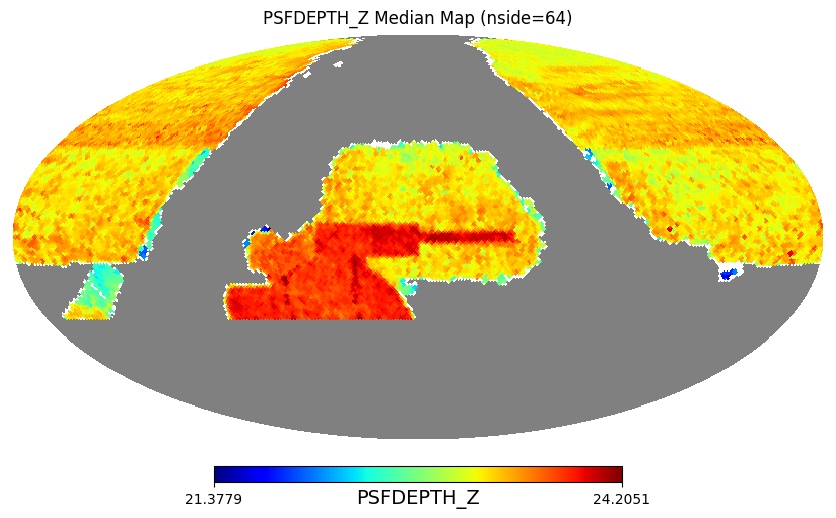

In [109]:
hp.mollview(median_maps['full'][64]['PSFDEPTH_Z'], cmap='jet', unit="PSFDEPTH_Z", title="PSFDEPTH_Z Median Map (nside=64)", nest=False)

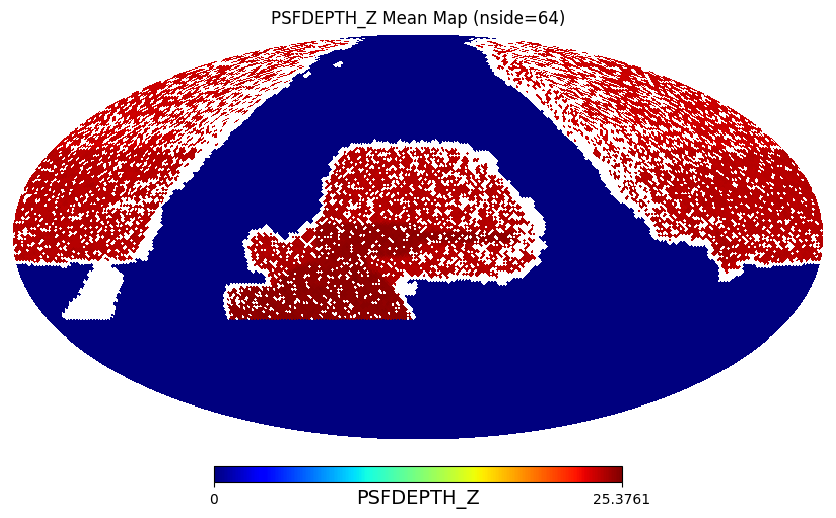

In [114]:
hp.mollview(maps['full'][64]['PSFDEPTH_R'], cmap='jet', unit="PSFDEPTH_Z", title="PSFDEPTH_Z Mean Map (nside=64)", nest=False)

(array([7.0400e+02, 0.0000e+00, 7.0000e+00, 2.3000e+01, 1.5780e+03,
        1.0292e+04, 6.5510e+03, 1.8290e+03, 3.0900e+02, 2.0000e+01]),
 array([0.        , 0.21599412, 0.43198824, 0.64798236, 0.86397648,
        1.0799706 , 1.29596472, 1.51195884, 1.72795296, 1.94394708,
        2.1599412 ]),
 <BarContainer object of 10 artists>)

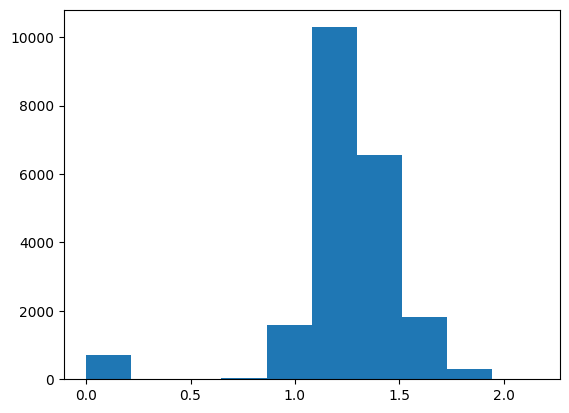

In [ ]:
plt.hist(median_maps['full'][64]['PSFSIZE_Z'][masks_dict['full'][64]==1])

In [55]:
delta_maps = {}

for region in data.keys():
    dat = data[region]
    delta_maps[region] = {}
    for nside in nside_values_obj:
        mask = masks_dict[region][nside]
        counts = points_to_map(dat['RA'], dat['DEC'], nside=nside)
        counts_masked = np.where(mask, counts, hp.UNSEEN)
        mean_counts = np.nanmean(counts_masked[counts_masked != hp.UNSEEN])
        delta_map = np.where(mask, (counts_masked - mean_counts) / mean_counts, hp.UNSEEN)
        delta_maps[region][nside] = delta_map

        

In [56]:
counts = {}

for region in data.keys():
    dat = data[region]
    counts[region] = {}
    for nside in nside_values_obj:
        mask = masks_dict[region][nside]
        counts[region][nside] = points_to_map(dat['RA'], dat['DEC'], nside=nside)


counts_randoms = {}
for region in regions.keys():
    dat = regions[region]
    counts_randoms[region] = {}
    for nside in nside_values_obj:
        mask = masks_dict[region][nside]
        counts_randoms[region][nside] = points_to_map(dat['RA'], dat['DEC'], nside=nside)


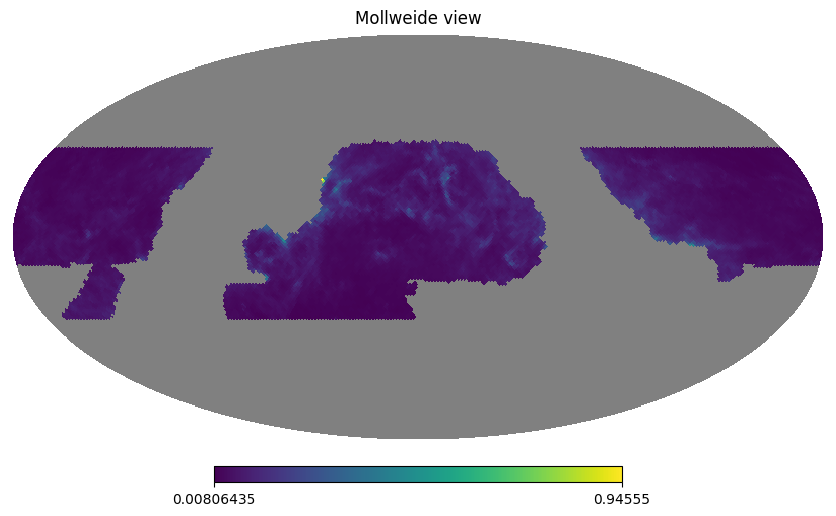

In [ ]:
 hp.mollview(np.where(masks_dict[region_name][nside_val], csfd_map_nside[nside_val], hp.UNSEEN))


In [57]:
df_full = {
    'map': delta_maps['full'][64],
    'mask': full_masks[64],
    'counts': counts['full'][64],
    'counts_randoms': counts_randoms['full'][64]
    
}
df_full

{'map': array([-1.6375e+30, -1.6375e+30, -1.6375e+30, ..., -1.6375e+30,
        -1.6375e+30, -1.6375e+30]),
 'mask': array([0, 0, 0, ..., 0, 0, 0], dtype='>i8'),
 'counts': array([0., 0., 0., ..., 0., 0., 0.]),
 'counts_randoms': array([0., 0., 0., ..., 0., 0., 0.])}

In [58]:
df_full = {
    'map': delta_maps['full'][64],
    'mask': full_masks[64],
    'counts': counts['full'][64],
    'counts_randoms': counts_randoms['full'][64]
    
}

# Add all median maps for the full region at nside=64
for colname in median_maps['full'][64].keys():
    df_full[colname] = median_maps['full'][64][colname]

df_full = Table(df_full)


In [ ]:
df_full

{'map': 20.0,
 'mask': array([0, 0, 0, ..., 0, 0, 0], dtype='>i8'),
 'median_counts': array([0., 0., 0., ..., 0., 0., 0.]),
 'PSFDEPTH_Z': array([-1.6375e+30, -1.6375e+30, -1.6375e+30, ..., -1.6375e+30,
        -1.6375e+30, -1.6375e+30]),
 'PSFDEPTH_G': array([-1.6375e+30, -1.6375e+30, -1.6375e+30, ..., -1.6375e+30,
        -1.6375e+30, -1.6375e+30]),
 'PSFDEPTH_R': array([-1.6375e+30, -1.6375e+30, -1.6375e+30, ..., -1.6375e+30,
        -1.6375e+30, -1.6375e+30]),
 'PSFSIZE_G': array([-1.6375e+30, -1.6375e+30, -1.6375e+30, ..., -1.6375e+30,
        -1.6375e+30, -1.6375e+30]),
 'PSFSIZE_R': array([-1.6375e+30, -1.6375e+30, -1.6375e+30, ..., -1.6375e+30,
        -1.6375e+30, -1.6375e+30]),
 'PSFSIZE_Z': array([-1.6375e+30, -1.6375e+30, -1.6375e+30, ..., -1.6375e+30,
        -1.6375e+30, -1.6375e+30]),
 'CSFD_EBV': array([-1.6375e+30, -1.6375e+30, -1.6375e+30, ..., -1.6375e+30,
        -1.6375e+30, -1.6375e+30]),
 'STELLAR_DENSITY_ALLWISE': array([-1.6375e+30, -1.6375e+30, -1.6375e+30, ..

In [59]:
for col in df_full.colnames:
    mask = df_full[col] == hp.UNSEEN
    if mask.any():
        df_full[col][mask] = np.nan

In [ ]:
df_full

map,mask,median_counts,PSFDEPTH_Z,PSFDEPTH_G,PSFDEPTH_R,PSFSIZE_G,PSFSIZE_R,PSFSIZE_Z,CSFD_EBV,STELLAR_DENSITY_ALLWISE,H_ALPHA
float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float32,float64
nan,0,0.0,nan,nan,nan,nan,nan,nan,nan,nan,nan
nan,0,0.0,nan,nan,nan,nan,nan,nan,nan,nan,nan
nan,0,0.0,nan,nan,nan,nan,nan,nan,nan,nan,nan
nan,0,0.0,nan,nan,nan,nan,nan,nan,nan,nan,nan
nan,0,0.0,nan,nan,nan,nan,nan,nan,nan,nan,nan
nan,0,0.0,nan,nan,nan,nan,nan,nan,nan,nan,nan
nan,0,0.0,nan,nan,nan,nan,nan,nan,nan,nan,nan
nan,0,0.0,nan,nan,nan,nan,nan,nan,nan,nan,nan
nan,0,0.0,nan,nan,nan,nan,nan,nan,nan,nan,nan


In [60]:
df_full.write('df_full_nside64.fits', overwrite=True)
print(f"Saved df_full table with {len(df_full)} pixels to 'df_full_nside64.fits'")

Saved df_full table with 49152 pixels to 'df_full_nside64.fits'


In [ ]:
df_full = Table.read('df_full_nside64.fits')

In [ ]:
X = df_full[['PSFDEPTH_Z',
 'PSFDEPTH_G',
 'PSFDEPTH_R',
 'PSFSIZE_G',
 'PSFSIZE_R',
 'PSFSIZE_Z',
 'CSFD_EBV',
 'STELLAR_DENSITY_ALLWISE',
 'H_ALPHA']][df_full['mask']==1].to_pandas().to_numpy()

Y = df_full[['map']][df_full['mask']==1].values()

In [ ]:
X

array([[        inf,         inf,         inf, ...,  0.06252339,
        30.74296951,  1.51083998],
       [        inf, 24.28212166, 23.54427338, ...,  0.06445709,
        30.01194   ,  1.44328898],
       [23.07489204, 24.30242348, 23.54986382, ...,  0.11115007,
        29.39893341,  1.24594785],
       ...,
       [23.32896233, 23.91656876, 24.03317642, ...,  0.06390363,
        33.46261597,  1.60739204],
       [23.29348183,         inf, 23.83789444, ...,  0.06970692,
        33.25765991,  1.81283063],
       [22.7258606 ,         inf,         inf, ...,  0.06042781,
        33.07369232,  2.09599897]])

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Replace inf with nan
X_clean = X.copy()
X_clean[np.isinf(X_clean)] = np.nan

# Impute nan values with median (or mean)
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X_clean)

# Now apply StandardScaler
scaler = StandardScaler()
Xn = scaler.fit_transform(X_imputed)



In [ ]:
Xn

array([[-1.08087065e-01, -2.41061139e+00, -1.97501922e+00, ...,
         3.58924988e-01,  4.29211189e-01,  8.22922764e-03],
       [-1.08087065e-01, -1.51467735e+00, -1.60556838e+00, ...,
         4.09367309e-01,  3.13556665e-01, -2.42112238e-02],
       [-1.00261407e+00, -1.35462406e+00, -1.73986859e+00, ...,
         1.62739457e+00,  2.16574280e-01, -1.18981611e-01],
       ...,
       [-1.76428757e-01, -2.44331025e+00, -2.89320431e-01, ...,
         3.94929774e-01,  8.59480298e-01,  5.45970414e-02],
       [-2.70339361e-01,  1.44604251e-01, -7.79646703e-01, ...,
         5.46313650e-01,  8.27054664e-01,  1.53256125e-01],
       [-2.38197326e+00,  1.44604251e-01,  1.42392994e-03, ...,
         3.04259933e-01,  7.97949568e-01,  2.89243868e-01]])

TypeError: Input should have at least 1 dimension i.e. satisfy `len(x.shape) > 0`, got scalar `array(odict_values([<Column name='map' dtype='float64' length=21354>
               -1.0
-0.8667861658237956
-0.8223815544317274
-0.7335723316475912
-0.9111907772158637
               -1.0
-0.6891677202555231
-0.7335723316475912
               -1.0
               -1.0
-0.9111907772158637
-0.4227400519031142
                ...
-0.6447631088634549
-0.8667861658237956
-0.8223815544317274
-0.7779769430396594
-0.9555953886079319
               -1.0
-0.5559538860793186
-0.9111907772158637
-0.8667861658237956
               -1.0
               -1.0]), dtype=object)` instead.

In [ ]:
psfdepth_z = df_full[df_full['mask']==1]['PSFDEPTH_Z']

# Count NaN elements
n_nan = np.isnan(psfdepth_z).sum()

# Count inf elements (both positive and negative infinity)
n_inf = np.isinf(psfdepth_z).sum()

# Count valid elements (non-NaN and non-inf)
n_valid = np.isfinite(psfdepth_z).sum()

# Total elements
n_total = len(psfdepth_z)

print(f"Total elements: {n_total}")
print(f"NaN elements: {n_nan}")
print(f"Inf elements: {n_inf}")
print(f"Valid elements (non-NaN, non-inf): {n_valid}")

Total elements: 21354
NaN elements: 40
Inf elements: 721
Valid elements (non-NaN, non-inf): 20593


In [ ]:
import pandas as pd

# Define nside values to iterate over
nside_values = [128, 256, 512, 1024, 2048]

# Dictionary to store results
density_results = {}

for ns in nside_values:
    # Calculate npix for this nside
    npix = hp.nside2npix(ns)
    pixarea = hp.nside2pixarea(ns, degrees=True)
    
    # Full sample
    pix_full = hp.ang2pix(ns, np.radians(90 - randoms_full["DEC"]), np.radians(randoms_full["RA"]), nest=True)
    area_full = len(np.unique(pix_full)) * pixarea
    density_full = len(randoms_full) / area_full
    
    # North sample
    pix_north = hp.ang2pix(ns, np.radians(90 - randoms_north["DEC"]), np.radians(randoms_north["RA"]), nest=True)
    area_north = len(np.unique(pix_north)) * pixarea
    density_north = len(randoms_north) / area_north
    
    # South sample
    pix_south = hp.ang2pix(ns, np.radians(90 - randoms_south["DEC"]), np.radians(randoms_south["RA"]), nest=True)
    area_south = len(np.unique(pix_south)) * pixarea
    density_south = len(randoms_south) / area_south
    
    density_results[ns] = {
        'full': {'count': len(randoms_full), 'area': area_full, 'density': density_full},
        'north': {'count': len(randoms_north), 'area': area_north, 'density': density_north},
        'south': {'count': len(randoms_south), 'area': area_south, 'density': density_south}
    }


print("=" * 100)
print(f"{'RANDOM CATALOG DENSITY ANALYSIS':^100}")
print("=" * 100)

for ns in nside_values:
    print(f"\n{'NSIDE = ' + str(ns):^100}")
    print("-" * 100)
    print(f"{'Region':<15} {'Count':>15} {'Area (deg²)':>20} {'Density (obj/deg²)':>25}")
    print("-" * 100)
    
    for region in ['full', 'north', 'south']:
        count = density_results[ns][region]['count']
        area = density_results[ns][region]['area']
        density = density_results[ns][region]['density']
        print(f"{region.upper():<15} {count:>15,} {area:>20,.2f} {density:>25,.2f}")
    print("-" * 100)

print("\n" + "=" * 100)

                                  RANDOM CATALOG DENSITY ANALYSIS                                   

                                            NSIDE = 128                                             
----------------------------------------------------------------------------------------------------
Region                    Count          Area (deg²)        Density (obj/deg²)
----------------------------------------------------------------------------------------------------
FULL                  5,000,000            17,616.14                    283.83
NORTH                 1,487,224             5,255.03                    283.01
SOUTH                 3,512,776            12,449.24                    282.17
----------------------------------------------------------------------------------------------------

                                            NSIDE = 256                                             
----------------------------------------------------------------------------

In [ ]:
nside =256
npix = hp.nside2npix(nside)
ra_full,dec_full = data['full'][['RA','DEC']].to_pandas().values.T

pix_full  = hp.ang2pix(nside, np.radians(90.0 - dec_full), np.radians(ra_full),nest=True)

counts_full = np.bincount(pix_full, minlength=npix)
full_density = counts_full / pixarea  # objects per square degree 

ra_north,dec_north = data['north'][['RA','DEC']].to_pandas().values.T

pix_north  = hp.ang2pix(nside, np.radians(90.0 - dec_north), np.radians(ra_north),nest=True)

counts_north = np.bincount(pix_north, minlength=npix)
north_density = counts_north / pixarea  # objects per square degree 

In [ ]:
north_density

array([0., 0., 0., ..., 0., 0., 0.])

In [ ]:
ra_south, dec_south = data['south'][['RA','DEC']].to_pandas().values.T

pix_south = hp.ang2pix(nside, np.radians(90.0 - dec_south), np.radians(ra_south), nest=True)

counts_south = np.bincount(pix_south, minlength=npix)
south_density = counts_south / pixarea  # objects per square degree

In [ ]:
#Saggitarius stream
#data extracted from the source https://cdsarc.u-strasbg.fr/viz-bin/cat/J/A+A/666/A64#/browse given in paper https://arxiv.org/pdf/2408.15909

In [ ]:

colspecs = [
    (0,19),   # GaiaEDR3
    (20,30),  # Gmag
    (31,41),  # BP-RP
    (42,57),  # RAdeg
    (58,73),  # DEdeg
    (74,83),  # pmRA
    (84,93),  # pmDE
    (94,99),  # e_pmRA
    (100,105),# e_pmDE
    (106,118),# DistWGBPRP
    (119,129),# e_DistWGBPRP
    (130,143),# Vlos
    (144,148),# r_Vlos
    (149,157),# [Fe/H]APOGEE
    (158,166),# [alpha/M]APOGEE
    (167,173),# [Fe/H]LAMOST
    (174,180),# [Fe/H]SEGUE
    (181,188),# SNRAPOGEE
    (189,195),# SNRgLAMOST
    (196,203),# SNRSEGUE
    (204,216),# ProbBright
    (217,229),# ProbFaint
    (230,242),# ProbSGR
    (243,255) # ProbPlx
]

names = [
    "GaiaEDR3", "Gmag", "BP_RP", "RAdeg", "DEdeg",
    "pmRA", "pmDE", "e_pmRA", "e_pmDE",
    "DistWGBPRP", "e_DistWGBPRP", "Vlos", "r_Vlos",
    "FeH_APOGEE", "AlphaM_APOGEE", "FeH_LAMOST",
    "FeH_SEGUE", "SNR_APOGEE", "SNRg_LAMOST",
    "SNR_SEGUE", "ProbBright", "ProbFaint",
    "ProbSGR", "ProbPlx"
]

df = pd.read_fwf(
    '../tablec1.dat',
    colspecs=colspecs,
    names=names,
    comment='#'
)




In [ ]:
df.head()

,GaiaEDR3,Gmag,BP_RP,RAdeg,DEdeg,pmRA,pmDE,e_pmRA,e_pmDE,DistWGBPRP,...,AlphaM_APOGEE,FeH_LAMOST,FeH_SEGUE,SNR_APOGEE,SNRg_LAMOST,SNR_SEGUE,ProbBright,ProbFaint,ProbSGR,ProbPlx
0,2364786972881162880,13.713778,1.581179,2.262514,-20.488732,-1.823,-3.431,0.023,0.017,---,...,0.11198,---,---,196.041,---,---,0.952779,0.000009,0.952780,0.991764
1,2499918360683828736,14.313960,1.922393,35.905505,-0.699945,-0.203,-1.997,0.030,0.026,---,...,-0.07890,---,---,124.315,---,---,0.967210,0.000100,0.967213,1.008520
2,6592952649661853952,16.674950,1.202846,326.599888,-31.123218,-2.336,-2.485,0.076,0.055,---,...,0.25179,---,---,20.136,---,---,0.990754,0.008220,0.990830,0.994589
3,6761669857110812288,15.331275,1.867418,283.762357,-29.381597,-2.765,-1.609,0.032,0.027,---,...,-0.01598,---,---,151.889,---,---,0.771522,0.000000,0.771522,0.994589
4,2364933792043225472,14.818077,1.764857,3.011098,-19.712606,-0.906,-2.666,0.036,0.024,---,...,0.02726,---,---,181.230,---,---,0.988319,0.000017,0.988320,0.987946


In [ ]:
hpx_map

array([ 1.15093899e+00,  1.16590309e+00,  1.16339743e+00, ...,
       -1.63750000e+30, -1.63750000e+30, -1.63750000e+30])

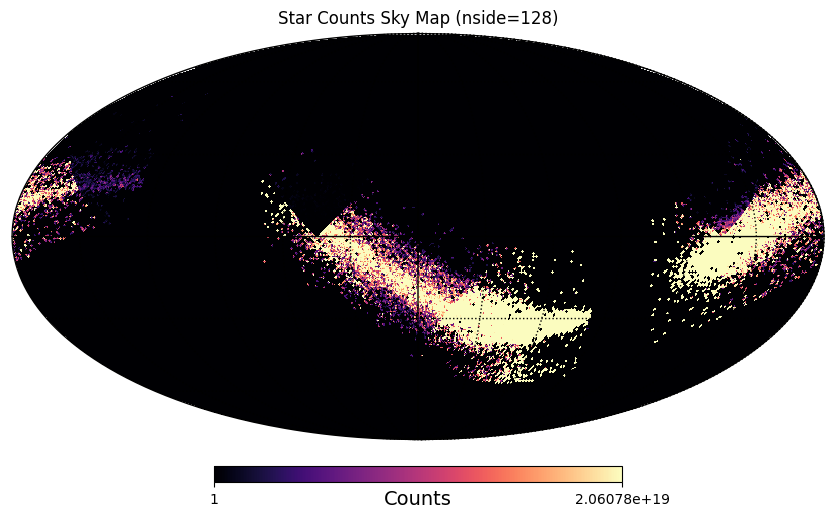

In [ ]:
nside = 128
npix = hp.nside2npix(nside)
ra = df['RAdeg'].values
dec = df['DEdeg'].values
theta = np.radians(90.0 - dec)
phi = np.radians(ra)
pix = hp.ang2pix(nside, theta, phi, nest=True)

hpx_map_stream = points_to_map(ra, dec, nside=nside,weights=df['GaiaEDR3'])
#smooting
sigma_deg = 0.00
fwhm_deg = sigma_deg * np.sqrt(8.0 * np.log(2.0))   # ≈ 2.355 deg
fwhm_rad = np.radians(fwhm_deg)
# counts_smoothed = hp.sphtfunc.smoothing(
#     counts,
#     fwhm=fwhm_rad,
# )
hp.mollview(hpx_map_stream, min=1,max = np.percentile(hpx_map_stream[hpx_map_stream > 0], 50),cmap='magma', unit="Counts", title=f"Star Counts Sky Map (nside={nside})",nest=False)

hp.graticule()
plt.show()

In [ ]:
# !wget https://cdsarc.u-strasbg.fr/ftp/J/A+A/666/A64/tablec1.dat.gz


In [ ]:
from pyvo import registry  # version >=1.6

# Moc and HEALPix tools
from mocpy import MOC

# Coordinates manipulation
from astropy.coordinates import SkyCoord

# Sky visualization
from ipyaladin import Aladin  # version >=0.4.0

In [ ]:
csfd_map.min()
csfd_map.max()

170.12773

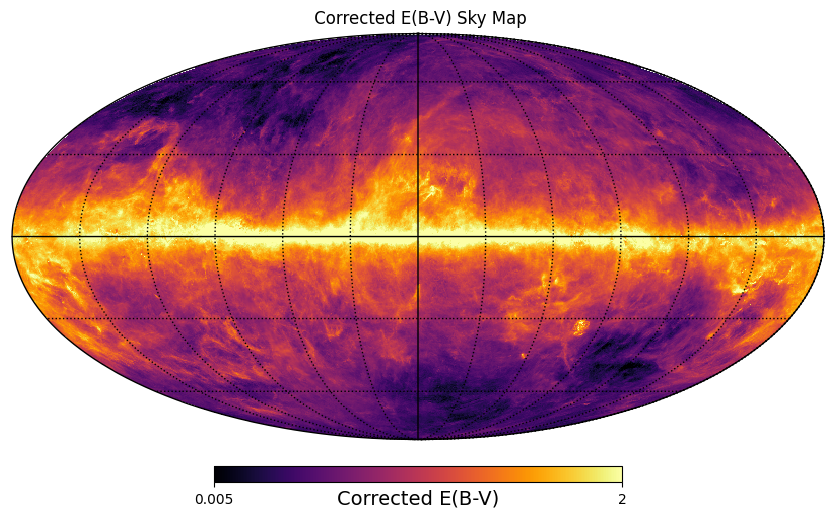

Downgraded csfd_map to nside=32, shape: (12288,)
Downgraded csfd_map to nside=64, shape: (49152,)
Downgraded csfd_map to nside=128, shape: (196608,)


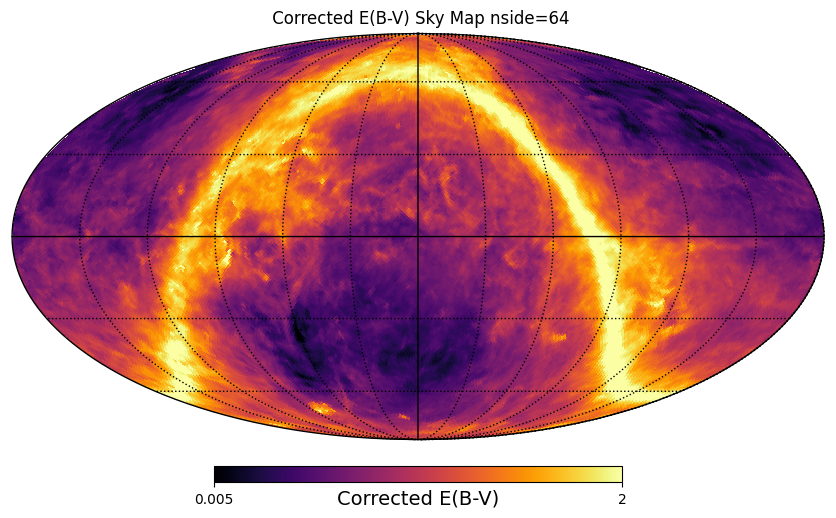

In [ ]:
csfd_masked_desi =csfd_map_256_eq*full_masks[256]

masked = np.where(full_masks[256], csfd_masked_desi, hp.UNSEEN)
hp.mollview(masked, cmap='jet', unit="Corrected E(B-V)", min=3e-3, max=0.2, title="CSFD Sky Map", nest=False, cbar=True, notext=False, )
hp.graticule()
plt.show()

NameError: name 'csfd_map_256_eq' is not defined

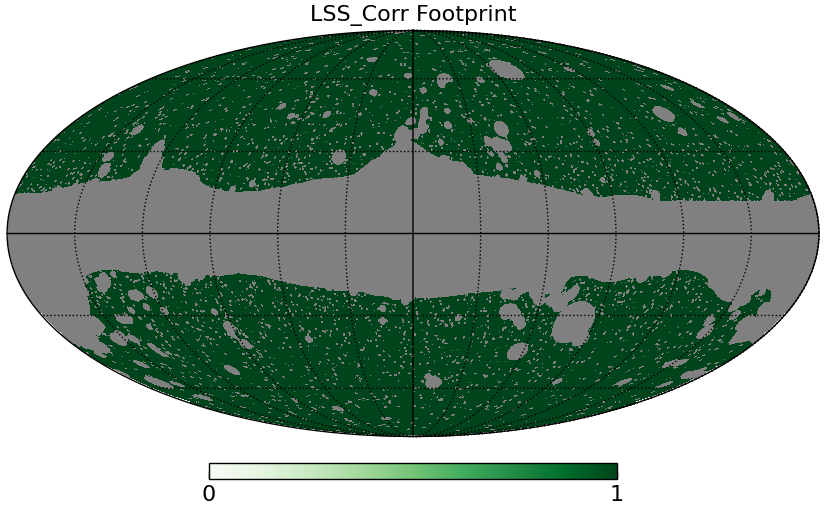

In [ ]:
# Bit 0 = LSS_corr
LSS_BIT = 0
lss_corr_mask = (cosmo_mask & (1 << LSS_BIT)) > 0   # boolean array
lss_og = np.where(lss_corr_mask, lss_intensity_map, hp.UNSEEN)
plot_map = np.where(lss_corr_mask, 1.0, hp.UNSEEN)
hp.mollview(plot_map, cmap='Greens', min=0,max =1,title=f"LSS_Corr Footprint", nest=False)
hp.graticule()
plt.show()


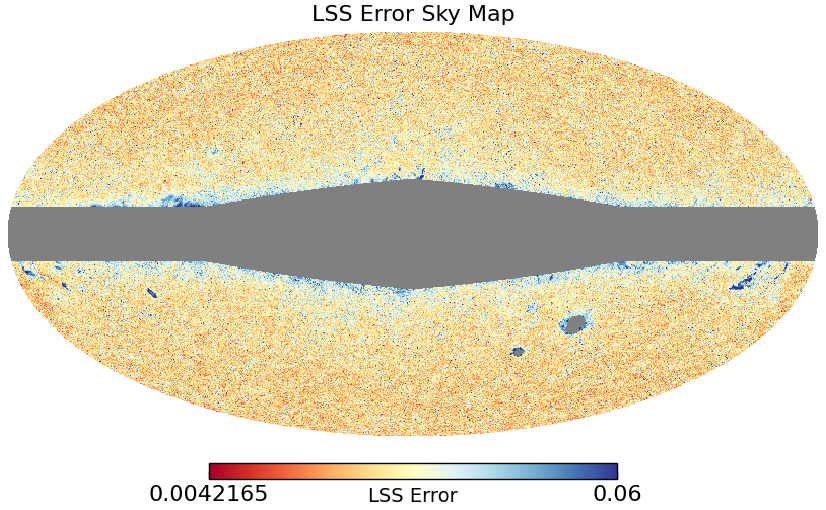

In [ ]:
hp.mollview(lss_error_map, cmap='RdYlBu', unit="LSS Error",max = 0.06, norm ='log',title=f"LSS Error Sky Map", nest=False)
plt.show()

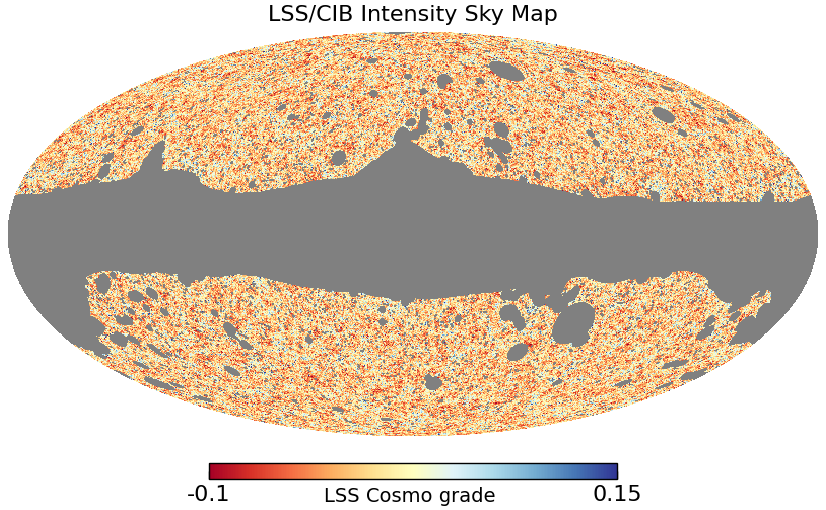

Fraction of sky usable: 0.5826851924260458


In [ ]:
hp.mollview(lss_cosmo, cmap='RdYlBu', min=-0.1,max =0.15,unit="LSS Cosmo grade ",title=f"LSS/CIB Intensity Sky Map", nest=False)
plt.show()
print("Fraction of sky usable:", cosmo_mask.mean())

In [ ]:
lss_cosmo_256 = hp.ud_grade(lss_cosmo, nside_out=nside_target, order_in='RING', order_out='RING', power=0)
lss_cosmo_map_256_eq = rotator.rotate_map_pixel(lss_cosmo_256)


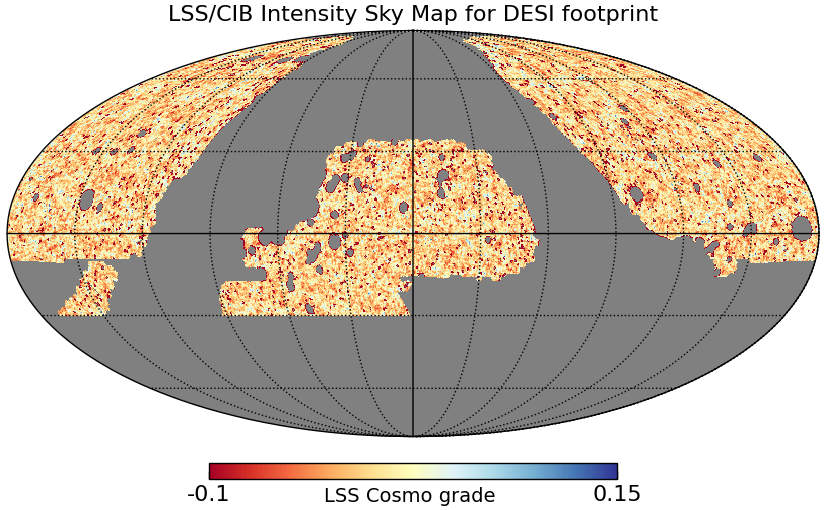

In [ ]:

masked = np.where(full_masks[256], lss_cosmo_masked_desi, hp.UNSEEN)
hp.mollview(masked, cmap='RdYlBu', min=-0.1,max =0.15,unit="LSS Cosmo grade ",title=f"LSS/CIB Intensity Sky Map for DESI footprint", nest=False, cbar=True, notext=False )
hp.graticule()
plt.show()

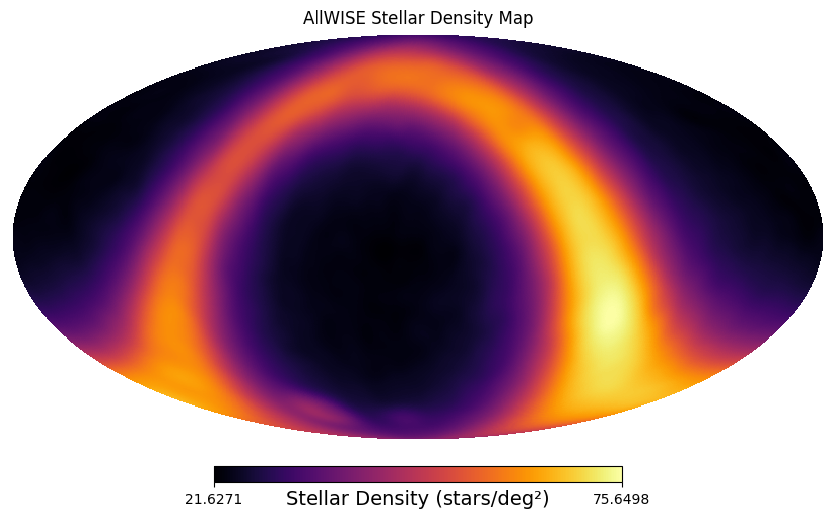

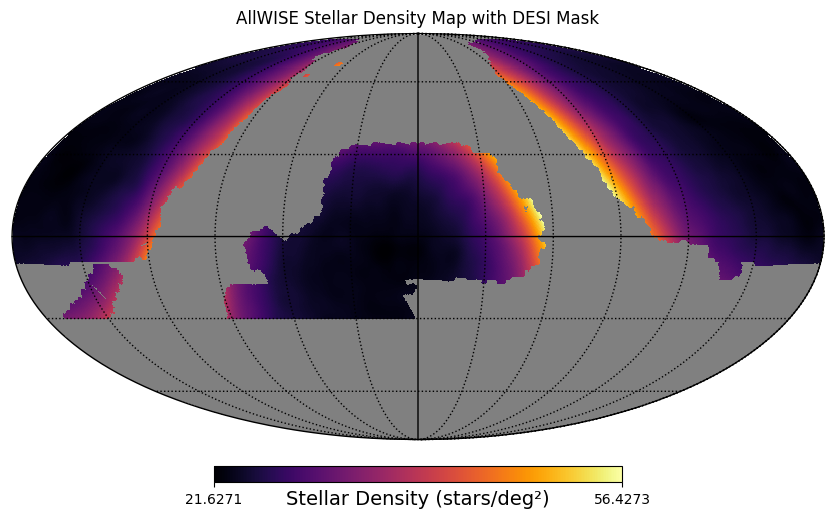

(array([4213344., 1959408., 1231360.,  973616.,  827504.,  867456.,
         851072.,  753424.,  576656.,  329072.]),
 array([21.62713623, 27.02940369, 32.43167114, 37.83394241, 43.23620987,
        48.63847733, 54.04074478, 59.44301224, 64.84528351, 70.24755096,
        75.64981842]),
 <BarContainer object of 10 artists>)

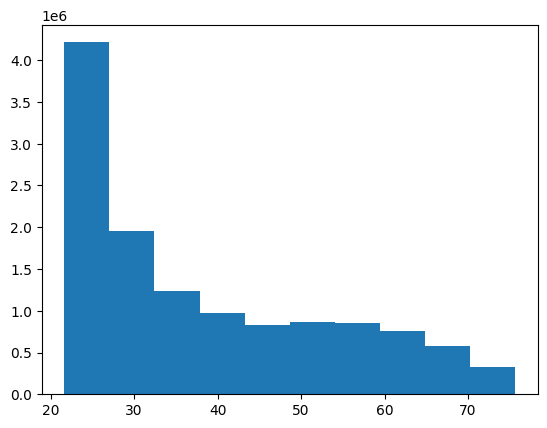

In [ ]:
plt.hist(stellar_denisty)